In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

In [10]:
torch.cuda.is_available()

True

In [11]:
ransomware = set(["WannaCry", "Ryuk", "REvil", "LockBit", "Darkside", "Conti"])

# Read Data

In [247]:
orig_df = pd.read_pickle('all_sys_config_10s_1s.pkl')

In [248]:
# remove mix
orig_df = orig_df[~orig_df['sys_config'].str.contains('mix')]

In [249]:
orig_df['start_s'] = orig_df['start'].apply(lambda x: x.seconds)
orig_df['end_s'] = orig_df['end'].apply(lambda x: x.seconds)

In [250]:
orig_df = orig_df.sort_values(by=['sys_config', 'operation', 'execution_log_cnt', 'start_s']).reset_index(drop=True)

In [251]:
orig_df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,...,1.0,1.000000,1.956988e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,...,1.0,0.750000,1.937112e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1,11
2,0 days 00:00:02,0 days 00:00:12,4933632.0,1436620.8,6.893165e+14,2.360246e+15,0.609265,0.008803,0.771016,9.0,...,1.0,1.333333,1.937112e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,2,12
3,0 days 00:00:03,0 days 00:00:13,9907865.6,2446643.2,3.884602e+14,2.456015e+15,0.636874,0.010777,0.767203,9.0,...,1.0,1.666667,1.357491e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,3,13
4,0 days 00:00:04,0 days 00:00:14,14008320.0,3856076.8,3.511144e+14,2.555528e+15,0.663654,0.015945,0.767203,9.0,...,1.0,1.666667,1.357491e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,4,14


In [252]:
benign_df = orig_df[~orig_df['operation'].isin(ransomware)].copy()

In [253]:
variants_df = pd.read_pickle('processed_dataset\conti_variants_dataset_10s_1s.pkl')

In [254]:
variants_df['start_s'] = variants_df['start'].apply(lambda x: x.seconds)
variants_df['end_s'] = variants_df['end'].apply(lambda x: x.seconds)

In [255]:
# Swap execution_log_cnt position
tmp_variants_cols = variants_df.columns.to_list()
tmp_variants_cols.remove('execution_log_cnt')
tmp_variants_cols.insert(107, 'execution_log_cnt')
variants_df = variants_df[tmp_variants_cols]

In [256]:
variants_df = variants_df.rename(columns = {
    'storage_entropy_high_entropy_count' : 'strg_write_high_entropy_count', 
    'storage_entropy_max_entropy_jump' : 'strg_write_max_entropy_jump', 
    'storage_entropy_time_to_high_entropy' : 'strg_write_time_to_high_entropy', 
    'storage_entropy_sustained_high_entropy_events' : 'strg_write_sustained_high_entropy_events', 
    'storage_entropy_storage_entropy_acceleration' : 'strg_write_entropy_acceleration', 
    'mem_write_entropy_high_entropy_count' : 'mem_write_high_entropy_count', 
    'mem_write_entropy_max_entropy_jump' : 'mem_write_max_entropy_jump', 
    'mem_write_entropy_time_to_high_entropy' : 'mem_write_time_to_high_entropy', 
    'mem_write_entropy_sustained_high_entropy_events' : 'mem_write_sustained_high_entropy_events', 
    'mem_write_entropy_storage_entropy_acceleration' : 'mem_write_entropy_acceleration', 
    'mem_read_write_entropy_high_entropy_count' : 'mem_read_write_high_entropy_count', 
    'mem_read_write_entropy_max_entropy_jump' : 'mem_read_write_max_entropy_jump', 
    'mem_read_write_entropy_time_to_high_entropy' : 'mem_read_write_time_to_high_entropy', 
    'mem_read_write_entropy_sustained_high_entropy_events' : 'mem_read_write_sustained_high_entropy_events', 
    'mem_read_write_entropy_storage_entropy_acceleration' : 'mem_read_write_entropy_acceleration'
})

In [257]:
variants_df = variants_df.sort_values(by=['sys_config', 'operation', 'execution_log_cnt', 'start_s']).reset_index(drop=True)

In [258]:
variants_df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,execution_log_cnt,operation,execution_id,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,4849664.0,26624.0,7.216492e+14,3.054669e+15,0.293940,0.014372,0.724932,11,...,1.0,1.048000,1.933847e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,5493555.2,30310.4,1.936776e+15,2.753770e+15,0.329643,0.009406,0.609391,5,...,1.0,1.076923,1.797322e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,1,11
2,0 days 00:00:02,0 days 00:00:12,7236864.0,245350.4,2.214443e+15,1.456105e+15,0.065303,0.007123,0.605647,3,...,1.0,0.750000,1.489127e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,2,12
3,0 days 00:00:03,0 days 00:00:13,7053260.8,409600.0,2.353752e+15,3.221578e+15,0.189868,0.005405,0.618514,7,...,1.0,0.571429,1.409014e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,3,13
4,0 days 00:00:04,0 days 00:00:14,7081267.2,601292.8,2.346414e+15,3.594887e+15,0.289372,0.004294,0.610371,7,...,1.0,0.571429,1.409014e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,4,14


In [259]:
variants_df['operation'].unique()

array(['Conti_01', 'Conti_02', 'Conti_03', 'Conti_04', 'Conti_05',
       'Conti_06', 'Conti_07'], dtype=object)

In [260]:
benign_df.head(2)

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,...,1.0,1.00,1.956988e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,...,1.0,0.75,1.937112e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1,11


In [261]:
variants_df.head(2)

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,execution_log_cnt,operation,execution_id,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,4849664.0,26624.0,7.216492e+14,3.054669e+15,0.293940,0.014372,0.724932,11,...,1.0,1.048000,1.933847e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,5493555.2,30310.4,1.936776e+15,2.753770e+15,0.329643,0.009406,0.609391,5,...,1.0,1.076923,1.797322e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,1,11


In [196]:
variants_df.head(2)

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,execution_log_cnt,operation,execution_id,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,4849664.0,26624.0,7.216492e+14,3.054669e+15,0.293940,0.014372,0.724932,11,...,1.0,1.048000,1.933847e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,5493555.2,30310.4,1.936776e+15,2.753770e+15,0.329643,0.009406,0.609391,5,...,1.0,1.076923,1.797322e+10,True,1,Conti_01,Conti_01_1,variants_i3-gen12_ddr4-2666-16g,1,11


# Null Imputation and Feature Selection

In [ ]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9
    

non_target_features = ['start', 'end']

# Obtained in EDA notebook
zero_var_features = ['num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec', 'mem_exec_burst_clustering', 'mem_write_seq_addr_access_ratio', 'mem_read_write_seq_addr_access_ratio']

high_corr_features = ['mem_exec_seq_addr_access_ratio', 'num_MMIO_pages_mem_write', 'strg_read_event_rate', 'strg_write_event_rate', 'mem_read_burst_intensity', 'mem_read_event_rate', 'mem_write_burst_intensity',
 'mem_write_event_rate', 'mem_read_write_micro_burst_count', 'mem_read_write_event_rate', 'mem_exec_burst_intensity', 'mem_exec_event_rate', 'strg_read_lba_range', 'strg_write_lba_range',
 'mem_read_gpa_range', 'mem_write_gpa_range', 'mem_read_write_gpa_range', 'mem_exec_avg_gpa_jump', 'mem_exec_gpa_range', 'end_s']


def preprocess(df):
    df = df.drop(columns= zero_var_features + high_corr_features)
    df["is_ransomware"] = df["is_ransomware"].astype(int)

    window_delta = df.iloc[0]['end'] - df.iloc[0]['start']
    step_delta = df['start'].diff()[1]

    time_to_high_entropy_cols = [col for col in df.columns if 'time_to_high_entropy' in col]
    df[time_to_high_entropy_cols] = df[time_to_high_entropy_cols].fillna(timedelta_to_ns(window_delta+step_delta))
    df = df.fillna(0)
    return df


In [ ]:
orig_df = preprocess(orig_df)
variants_df = preprocess(variants_df)

In [ ]:
orig_df = orig_df.drop(columns = ['start', 'end'])
variants_df = variants_df.drop(columns = ['start', 'end'])

In [264]:
feature_cols = orig_df.drop(columns=['is_ransomware', 'operation', 'execution_log_cnt', 'sys_config', 'execution_id']).columns.to_list()
feature_cols

['avg_ata_read',
 'avg_ata_write',
 'lba_read_var',
 'lba_write_var',
 'avg_storage_entropy',
 'avg_entropy_mem_write',
 'avg_entropy_mem_read_write',
 'num_4KB_pages_mem_read',
 'num_4KB_pages_mem_write',
 'num_4KB_pages_mem_read_write',
 'num_4KB_pages_mem_exec',
 'num_2MB_pages_mem_read',
 'num_2MB_pages_mem_write',
 'num_2MB_pages_mem_read_write',
 'num_2MB_pages_mem_exec',
 'num_MMIO_pages_mem_read',
 'gpa_mem_read_var',
 'gpa_mem_write_var',
 'gpa_mem_read_write_var',
 'gpa_mem_exec_var',
 'strg_write_high_entropy_count',
 'strg_write_max_entropy_jump',
 'strg_write_time_to_high_entropy',
 'strg_write_sustained_high_entropy_events',
 'strg_write_entropy_acceleration',
 'mem_write_high_entropy_count',
 'mem_write_max_entropy_jump',
 'mem_write_time_to_high_entropy',
 'mem_write_sustained_high_entropy_events',
 'mem_write_entropy_acceleration',
 'mem_read_write_high_entropy_count',
 'mem_read_write_max_entropy_jump',
 'mem_read_write_time_to_high_entropy',
 'mem_read_write_sustaine

# Preprocess Data

In [ ]:
class RansomwareDataset(Dataset):
    def __init__(self, df, feature_columns, pad_to_length=None, pad_value=0.0):
        """
        Args:
            df: DataFrame
            feature_columns: List of 81 feature column names
            pad_to_length: Fixed length to pad all sequences to (default: max length in dataset)
            pad_value: Value to use for padding (default: 0.0)
        """
        self.feature_columns = feature_columns
        self.pad_value = pad_value
        
        self.sequences = []
        self.labels = []
        self.lengths = []
        self.metadata = []
        
        groupby_cols = ['sys_config', 'operation', 'execution_log_cnt']
        
        for (config, app, exec_id), group in df.groupby(groupby_cols):
            group = group.sort_values('start_s')
            
            features = group[feature_columns].values  # (num_wind, 81)
            label = group['is_ransomware'].iloc[0]
            original_length = len(features)
            
            self.sequences.append(features)
            self.labels.append(label)
            self.lengths.append(original_length)
            self.metadata.append({
                'system_config': config,
                'application': app,
                'execution_id': exec_id,
                'original_length': original_length
            })
        
        # print("Created sequences")
        if pad_to_length is None:
            self.pad_to_length = max(self.lengths)
        else:
            self.pad_to_length = pad_to_length
        
        # print(f"Performing padding with length: {self.pad_to_length}")
        self.sequences_padded = self._pad_sequences()
        # print("Finished padding")
        self.sequences_padded = np.array(self.sequences_padded, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
        self.lengths = np.array(self.lengths, dtype=np.int64)
        
        print(f"{'-'*70}")
        print(f"DATASET SUMMARY")
        print(f"{'-'*70}")
        print(f"Total sequences: {len(self.sequences_padded)}")
        print(f"Sequence lengths: min={min(self.lengths)}, max={max(self.lengths)}, "
              f"mean={np.mean(self.lengths):.1f}")
        print(f"Padded sequence shape: {self.sequences_padded.shape}")
        print(f"  - Batch dimension: variable (set by DataLoader)")
        print(f"  - Sequence dimension: {self.pad_to_length}")
        print(f"  - Feature dimension: {len(feature_columns)}")
        print(f"Class distribution:")
        print(f"  - Benign: {np.sum(self.labels == 0)}")
        print(f"  - Ransomware: {np.sum(self.labels == 1)}")
        if 'hardware_config' in self.metadata[0]:
            hw_counts = pd.Series([m['hardware_config'] for m in self.metadata]).value_counts()
            print(f"Hardware distribution:")
            for hw, count in hw_counts.items():
                print(f"  - {hw}: {count}")
        print(f"{'-'*70}\n")
    
    def _pad_sequences(self):
        """Pad all sequences to the same length"""
        padded_sequences = []
        
        for seq in self.sequences:
            current_length = len(seq)
            
            if current_length < self.pad_to_length:
                pad_length = self.pad_to_length - current_length
                padding = np.full((pad_length, seq.shape[1]), self.pad_value)
                padded_seq = np.vstack([seq, padding])
            elif current_length > self.pad_to_length:
                padded_seq = seq[:self.pad_to_length]
            else:
                padded_seq = seq
            
            padded_sequences.append(padded_seq)
        
        return padded_sequences
    
    def __len__(self):
        return len(self.sequences_padded)
    
    def __getitem__(self, idx):
        """
        Returns:
            sequence: Padded sequence tensor (pad_to_length, num_features)
            label: Binary label (0 or 1)
            length: Original sequence length before padding
        """
        sequence = torch.tensor(self.sequences_padded[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        length = torch.tensor(self.lengths[idx], dtype=torch.long)
        
        return sequence, label, length

In [ ]:
def prepare_data(df, feature_columns, Td, train_apps, test_apps, batch_size=16, shuffle=True):
    
    # if test_apps is not None:
    train_df = df[(df['operation'].isin(train_apps)) & (~(df['sys_config'].str.contains('extra')))].copy()
    test_df = df[(df['operation'].isin(test_apps))].copy()
    # else:
    #     train_df = df[~(df['sys_config'].str.contains('extra'))].copy()
    #     test_df = df[df['sys_config'].str.contains('extra')].copy()
    
    print(f"\n{'='*70}")
    print(f"DATA SPLIT for {'unseen' if test_apps is not None else 'seen'} with Td={Td}")
    print(f"{'='*70}")
    print(f"Training applications: {train_apps}")
    print(f"Testing applications: {test_apps if test_apps is not None else 'all'}")
    # print(f"Training executions: {len(train_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    # print(f"Testing executions: {len(test_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"{'='*70}\n")
    
    scaler = StandardScaler()
    train_df[feature_columns] = scaler.fit_transform(train_df[feature_columns])
    test_df[feature_columns] = scaler.transform(test_df[feature_columns])
    
    print(f"{'-'*70}")
    print(f"TRAIN SET")
    train_dataset = RansomwareDataset(train_df, feature_columns, Td)
    print(f"{'-'*70}")
    print(f"TEST SET")
    test_dataset = RansomwareDataset(test_df, feature_columns, Td)
    
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    if not shuffle:
        return train_loader, test_loader, scaler, test_dataset.metadata
    
    return train_loader, test_loader, scaler, test_dataset.metadata


In [270]:
conti_variants = variants_df['operation'].unique()
orig_apps_wo_conti = orig_df[orig_df['operation'] != 'Conti']['operation'].unique()
orig_apps_wo_conti, conti_variants


(array(['AESCrypt', 'Darkside', 'Firefox', 'Idle', 'LockBit', 'Office',
        'REvil', 'Ryuk', 'SDelete', 'WannaCry', 'Zip'], dtype=object),
 array(['Conti_01', 'Conti_02', 'Conti_03', 'Conti_04', 'Conti_05',
        'Conti_06', 'Conti_07'], dtype=object))

In [ ]:
df = pd.concat([orig_df, variants_df])

In [289]:
df.head(2)

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s
0,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,0.0,0.0,...,0.952381,1.937112e+10,1.0,1.00,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0
1,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,0.0,0.0,...,0.833333,1.937112e+10,1.0,0.75,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1


In [276]:
for c_ind, conti_variant in enumerate(conti_variants):
    print("i", c_ind)
    print("Train: ", conti_variants[:c_ind])
    print("Test: ", conti_variants[c_ind:])
    print('-'*30)

i 0
Train:  []
Test:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06'
 'Conti_07']
------------------------------
i 1
Train:  ['Conti_01']
Test:  ['Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06' 'Conti_07']
------------------------------
i 2
Train:  ['Conti_01' 'Conti_02']
Test:  ['Conti_03' 'Conti_04' 'Conti_05' 'Conti_06' 'Conti_07']
------------------------------
i 3
Train:  ['Conti_01' 'Conti_02' 'Conti_03']
Test:  ['Conti_04' 'Conti_05' 'Conti_06' 'Conti_07']
------------------------------
i 4
Train:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04']
Test:  ['Conti_05' 'Conti_06' 'Conti_07']
------------------------------
i 5
Train:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05']
Test:  ['Conti_06' 'Conti_07']
------------------------------
i 6
Train:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06']
Test:  ['Conti_07']
------------------------------


In [360]:
variant_dataloaders_150 = {}

for c_ind, conti_variant in enumerate(conti_variants):
    
    train_apps = np.concatenate((orig_apps_wo_conti, conti_variants[:c_ind]))
    test_apps = conti_variants[c_ind:]
    
    train_loader, test_loader, _, test_metadata = prepare_data(df, feature_cols, 150, train_apps, test_apps)
    tmp_dict = {'train': train_loader, 'test': test_loader, 'test_metadata': test_metadata}
    variant_dataloaders_150[conti_variant] = tmp_dict



DATA SPLIT for unseen with Td=150
Training applications: ['AESCrypt' 'Darkside' 'Firefox' 'Idle' 'LockBit' 'Office' 'REvil' 'Ryuk'
 'SDelete' 'WannaCry' 'Zip']
Testing applications: ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06'
 'Conti_07']

----------------------------------------------------------------------
TRAIN SET
----------------------------------------------------------------------
DATASET SUMMARY
----------------------------------------------------------------------
Total sequences: 1318
Sequence lengths: min=32, max=312, mean=187.4
Padded sequence shape: (1318, 150, 81)
  - Batch dimension: variable (set by DataLoader)
  - Sequence dimension: 150
  - Feature dimension: 81
Class distribution:
  - Benign: 720
  - Ransomware: 598
----------------------------------------------------------------------

----------------------------------------------------------------------
TEST SET
----------------------------------------------------------------------
DATASET

# Models

## LSTM

In [299]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=81, hidden_size=64, num_layers=1, dropout=0.3):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=0)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x, lengths=None):
        lstm_out, (h_n, c_n) = self.lstm(x)
        final_hidden = h_n[-1]
        output = self.classifier(final_hidden)
        return output
    

# CNN

In [ ]:
class SimpleCNN1D(nn.Module):
    def __init__(self, input_size=81, num_filters=64, dropout=0.3):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(dropout),
            
            nn.Conv1d(num_filters, num_filters*2, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(dropout),
            
            nn.Conv1d(num_filters*2, num_filters*4, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters*4),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_filters*4, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x, lengths=None):
        """
        Args:
            x: (batch_size, 171, 81)
        Returns:
            output: (batch_size, 1)
        """
        x = x.transpose(1, 2)  # (batch, 81, 171)
        
        x = self.conv_layers(x)  # (batch, num_filters*4, 1)
        
        x = x.squeeze(-1)  # (batch, num_filters*4)
        
        output = self.classifier(x)
        
        return output

# Training Pipeline

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (sequences, labels, lengths) in enumerate(dataloader):
        sequences = sequences.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device) if lengths is not None else None
        
        optimizer.zero_grad()
        outputs = model(sequences, lengths).squeeze()
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, preds_binary),
        'precision': precision_score(all_labels, preds_binary, zero_division=0),
        'recall': recall_score(all_labels, preds_binary, zero_division=0),
        'f1': f1_score(all_labels, preds_binary, zero_division=0),
    }
    
    return metrics


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, labels, lengths in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device) if lengths is not None else None
            
            outputs = model(sequences, lengths).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
    }
    
    return metrics, all_preds, all_probs, all_labels


def train_model(model, train_loader, val_loader, epochs=100, device='cuda', 
                lr=0.001, patience=15, model_name='model'):

    model = model.to(device)
    
    # os.makedirs('./model_data/tmp', exist_ok=True)
    save_dir = os.path.join('model_data', model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_val_f1 = 0
    best_epoch = 0
    patience_counter = 0
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"Learning rate: {lr}")
    print(f"{'='*70}\n")
    
    for epoch in range(epochs):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)
        
        scheduler.step(val_metrics['loss'])
        
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['train_f1'].append(train_metrics['f1'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Train F1: {train_metrics['f1']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Val F1: {val_metrics['f1']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f}")
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': best_val_f1,
                'val_metrics': val_metrics
            }, os.path.join(save_dir, 'best_model.pth'))
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation F1: {best_val_f1:.4f} at epoch {best_epoch+1}")
            break
    
    checkpoint = torch.load(os.path.join(save_dir, 'best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"\n{'='*70}")
    print(f"TRAINING COMPLETED")
    print(f"Best Epoch: {best_epoch+1}")
    print(f"Best Validation F1: {best_val_f1:.4f}")
    print(f"Best Validation Accuracy: {checkpoint['val_metrics']['accuracy']:.4f}")
    print(f"Best Validation Precision: {checkpoint['val_metrics']['precision']:.4f}")
    print(f"Best Validation Recall: {checkpoint['val_metrics']['recall']:.4f}")
    print(f"{'='*70}\n")
    
    return model, history


In [ ]:
def train_and_evaluate(model, train_loader, test_loader, model_name, epochs, lr=0.001, patience=15):
    trained_model, history = train_model(
        model, 
        train_loader, 
        test_loader,
        epochs=epochs,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        lr=lr,
        patience=patience,
        model_name=model_name
    )


    test_metrics, test_preds, test_probs, test_labels = evaluate(
        trained_model, 
        test_loader, 
        nn.BCEWithLogitsLoss(), 
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    
    return trained_model, history, test_metrics, test_preds, test_labels

# Model Training

In [380]:
def plot_variant_heatmap(model_run_metrics, model_name):
    recall_heatmap = [[0 for _ in range(len(conti_variants))] for _ in range(len(conti_variants))]
    recall_heatmap

    for i, first_test_variant in enumerate(conti_variants):
        train_variant = 'orig' if i > 0 else conti_variants[i-1]

        for j, test_conti in enumerate(conti_variants[i:], start=i):
            recall = model_run_metrics[first_test_variant]['variant_res'][test_conti][2]
            recall_heatmap[j][i] = recall

    recall_heatmap = np.array(recall_heatmap)
    variants_heatmap_x_labels, variants_heatmap_y_labels = ['orig'] + conti_variants[:-1].tolist(), conti_variants.tolist()
    
    for i in range(recall_heatmap.shape[0]):
        for j in range(i+1, recall_heatmap.shape[1]):
            recall_heatmap[i][j] = np.nan

    plt.gcf().set_facecolor("#eeeeeeff")
    plt.figure(figsize=(6, 5))
    sns.heatmap(recall_heatmap, annot=True, fmt='g', cmap='viridis', xticklabels=variants_heatmap_x_labels, yticklabels=variants_heatmap_y_labels)

    plt.xlabel("Train variants: Conti_i ⇒ ≤ i in train set.")
    plt.ylabel("Test variants")
    plt.title(f"Recall Scores for different Conti Variants using {model_name} model")
    plt.show()
    

## LSTM

In [ ]:
model_run_metrics_150 = {}

for c_ind, conti_variant in enumerate(conti_variants):
    tmp_dict = {}
    train_conti_apps = np.concatenate((np.array(['Original']), conti_variants[:c_ind]))
    test_conti_apps = conti_variants[c_ind:]
    
    train_dataloader = variant_dataloaders_150[conti_variant]['train']
    test_dataloader = variant_dataloaders_150[conti_variant]['test']
    simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols))
    print("+" * 15, "Training Apps: ", train_conti_apps,"+" * 15 )
    print("+" * 15, "Testing Apps: ", test_conti_apps,"+" * 15 )
    simpleLSTM_trained_model, simpleLSTM_history, simpleLSTM_test_metrics, simpleLSTM_test_preds, simpleLSTM_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader, test_dataloader, 'simpleLSTM', epochs=100,)
    
    conti_res = {}
    
    for test_conti in test_conti_apps:
        conti_ind = [i for i, md in enumerate(variant_dataloaders_150[conti_variant]['test_metadata']) if md['application'] == test_conti]
        conti_test_preds = [simpleLSTM_test_preds[i] for i in conti_ind]
        conti_test_labels = [simpleLSTM_test_labels[i] for i in conti_ind]
        conti_res[test_conti] = (conti_test_labels, conti_test_preds, recall_score(conti_test_labels, conti_test_preds))
    
    tmp_dict['model'] = simpleLSTM_trained_model
    tmp_dict['history'] = simpleLSTM_history
    tmp_dict['metrics'] = simpleLSTM_test_metrics
    tmp_dict['variant_res'] = conti_res
    
    model_run_metrics_150[conti_variant] = tmp_dict
    


+++++++++++++++ Training Apps:  ['Original'] +++++++++++++++
+++++++++++++++ Testing Apps:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06'
 'Conti_07'] +++++++++++++++

TRAINING simpleLSTM
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.4803 | Train F1: 0.8027 | Val Loss: 1.3261 | Val F1: 0.5417 | Val Acc: 0.3714
Epoch   2/100 | Train Loss: 0.1160 | Train F1: 0.9728 | Val Loss: 3.0974 | Val F1: 0.5417 | Val Acc: 0.3714
Epoch   3/100 | Train Loss: 0.0290 | Train F1: 0.9933 | Val Loss: 2.9059 | Val F1: 0.5859 | Val Acc: 0.4143
Epoch   4/100 | Train Loss: 0.0299 | Train F1: 0.9933 | Val Loss: 5.0820 | Val F1: 0.2500 | Val Acc: 0.1429
Epoch   5/100 | Train Loss: 0.0085 | Train F1: 0.9983 | Val Loss: 5.2391 | Val F1: 0.2927 | Val Acc: 0.1714
Epoch   6/100 | Train Loss: 0.0140 | Train F1: 0.9966 | Val Loss: 5.6026 | Val F1: 0.2927 | Val Acc: 0.1714
Epoch   7/100 | Train Loss: 0.0185 | Train F1: 0.9966 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.4479 | Train F1: 0.8072 | Val Loss: 1.6000 | Val F1: 0.6047 | Val Acc: 0.4333
Epoch   2/100 | Train Loss: 0.1094 | Train F1: 0.9755 | Val Loss: 2.5784 | Val F1: 0.6517 | Val Acc: 0.4833
Epoch   3/100 | Train Loss: 0.0308 | Train F1: 0.9942 | Val Loss: 2.1011 | Val F1: 0.7500 | Val Acc: 0.6000
Epoch   4/100 | Train Loss: 0.0106 | Train F1: 0.9984 | Val Loss: 2.5768 | Val F1: 0.7234 | Val Acc: 0.5667
Epoch   5/100 | Train Loss: 0.0098 | Train F1: 0.9984 | Val Loss: 3.0092 | Val F1: 0.6813 | Val Acc: 0.5167
Epoch   6/100 | Train Loss: 0.0108 | Train F1: 0.9975 | Val Loss: 1.9617 | Val F1: 0.8350 | Val Acc: 0.7167
Epoch   7/100 | Train Loss: 0.0187 | Train F1: 0.9951 | Val Loss: 3.9566 | Val F1: 0.3562 | Val Acc: 0.2167
Epoch   8/100 | Train Loss: 0.0063 | Train F1: 0.9984 | Val Loss: 2.7228 | Val F1: 0.6957 | Val Acc: 0.5333
Epoch   9/100 | Train Loss: 0.0052 | Train F1: 0.9984 | Val Loss: 3.3911 | Val F1: 0.6517 | Val Acc: 0.4833
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.4288 | Train F1: 0.8478 | Val Loss: 1.8395 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   2/100 | Train Loss: 0.1018 | Train F1: 0.9760 | Val Loss: 2.6991 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   3/100 | Train Loss: 0.0455 | Train F1: 0.9903 | Val Loss: 2.2356 | Val F1: 0.7342 | Val Acc: 0.5800
Epoch   4/100 | Train Loss: 0.0247 | Train F1: 0.9943 | Val Loss: 3.5857 | Val F1: 0.3333 | Val Acc: 0.2000
Epoch   5/100 | Train Loss: 0.0233 | Train F1: 0.9943 | Val Loss: 2.4315 | Val F1: 0.6111 | Val Acc: 0.4400
Epoch   6/100 | Train Loss: 0.0087 | Train F1: 0.9968 | Val Loss: 1.7715 | Val F1: 0.8506 | Val Acc: 0.7400
Epoch   7/100 | Train Loss: 0.0033 | Train F1: 0.9984 | Val Loss: 1.6200 | Val F1: 0.8636 | Val Acc: 0.7600
Epoch   8/100 | Train Loss: 0.0030 | Train F1: 0.9992 | Val Loss: 1.5822 | Val F1: 0.8636 | Val Acc: 0.7600
Epoch   9/100 | Train Loss: 0.0010 | Train F1: 1.0000 | Val Loss: 1.7418 | Val F1: 0.8636 | Val Acc: 0.7600
Epoch  10/100 | Train Loss: 

...

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.4467 | Train F1: 0.8425 | Val Loss: 1.4840 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   2/100 | Train Loss: 0.0794 | Train F1: 0.9802 | Val Loss: 1.9962 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   3/100 | Train Loss: 0.0229 | Train F1: 0.9938 | Val Loss: 2.3279 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   4/100 | Train Loss: 0.0295 | Train F1: 0.9938 | Val Loss: 2.4441 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   5/100 | Train Loss: 0.0181 | Train F1: 0.9969 | Val Loss: 2.4688 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   6/100 | Train Loss: 0.0126 | Train F1: 0.9961 | Val Loss: 2.4487 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   7/100 | Train Loss: 0.0092 | Train F1: 0.9985 | Val Loss: 2.3176 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   8/100 | Train Loss: 0.0108 | Train F1: 0.9977 | Val Loss: 2.4681 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   9/100 | Train Loss: 0.0043 | Train F1: 0.9992 | Val Loss: 2.6654 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.4565 | Train F1: 0.8384 | Val Loss: 0.0794 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   2/100 | Train Loss: 0.1144 | Train F1: 0.9725 | Val Loss: 0.4208 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   3/100 | Train Loss: 0.0581 | Train F1: 0.9831 | Val Loss: 0.4911 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   4/100 | Train Loss: 0.0417 | Train F1: 0.9877 | Val Loss: 0.4558 | Val F1: 0.9474 | Val Acc: 0.9000
Epoch   5/100 | Train Loss: 0.0299 | Train F1: 0.9908 | Val Loss: 0.0030 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   6/100 | Train Loss: 0.0225 | Train F1: 0.9916 | Val Loss: 1.9304 | Val F1: 0.7500 | Val Acc: 0.6000
Epoch   7/100 | Train Loss: 0.0208 | Train F1: 0.9908 | Val Loss: 2.2829 | Val F1: 0.7500 | Val Acc: 0.6000
Epoch   8/100 | Train Loss: 0.0241 | Train F1: 0.9939 | Val Loss: 0.9586 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   9/100 | Train Loss: 0.0164 | Train F1: 0.9970 | Val Loss: 0.0008 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

In [ ]:
recall_heatmap = [[0 for _ in range(len(conti_variants))] for _ in range(len(conti_variants))]
recall_heatmap

for i, first_test_variant in enumerate(conti_variants):
    train_variant = 'orig' if i > 0 else conti_variants[i-1]

    for j, test_conti in enumerate(conti_variants[i:], start=i):
        recall = model_run_metrics_150[first_test_variant]['variant_res'][test_conti][2]
        recall_heatmap[j][i] = recall

recall_heatmap = np.array(recall_heatmap)
variants_heatmap_x_labels, variants_heatmap_y_labels = ['orig'] + conti_variants[:-1].tolist(), conti_variants.tolist()

In [364]:
for i in range(recall_heatmap.shape[0]):
    for j in range(i+1, recall_heatmap.shape[1]):
        recall_heatmap[i][j] = np.nan

recall_heatmap

array([[0.9, nan, nan, nan, nan, nan, nan],
       [0.4, 0.9, nan, nan, nan, nan, nan],
       [0.6, 0.9, 1. , nan, nan, nan, nan],
       [0.3, 0.8, 0.9, 1. , nan, nan, nan],
       [0.3, 0.9, 1. , 1. , 1. , nan, nan],
       [0. , 0. , 0. , 0. , 0. , 0. , nan],
       [0.4, 0.8, 0.9, 1. , 1. , 1. , 1. ]])

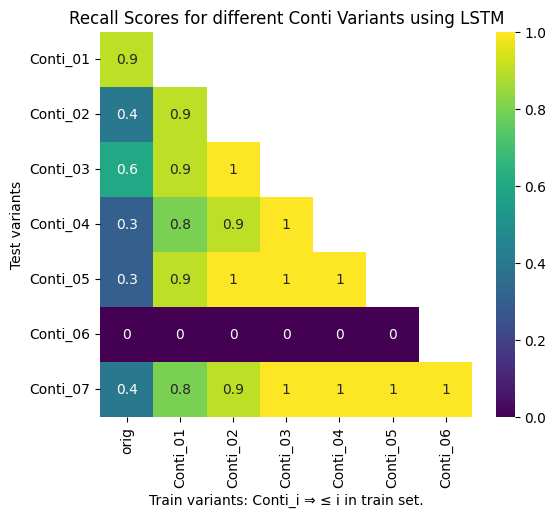

In [370]:
plot_variant_heatmap(model_run_metrics_150, model_name='LSTM')

## CNN 1D

In [ ]:
cnn1d_run_metrics_150 = {}

for c_ind, conti_variant in enumerate(conti_variants):
    tmp_dict = {}
    train_conti_apps = np.concatenate((np.array(['Original']), conti_variants[:c_ind]))
    test_conti_apps = conti_variants[c_ind:]
    
    train_dataloader = variant_dataloaders_150[conti_variant]['train']
    test_dataloader = variant_dataloaders_150[conti_variant]['test']
    model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
    print("+" * 15, "Training Apps: ", train_conti_apps,"+" * 15 )
    print("+" * 15, "Testing Apps: ", test_conti_apps,"+" * 15 )
    trained_model, history, test_metrics, test_preds, test_labels = train_and_evaluate(model, train_dataloader, test_dataloader, 'SimpleCNN1D', epochs=100,)

    conti_res = {}
    
    for test_conti in test_conti_apps:
        conti_ind = [i for i, md in enumerate(variant_dataloaders_150[conti_variant]['test_metadata']) if md['application'] == test_conti]
        conti_test_preds = [test_preds[i] for i in conti_ind]
        conti_test_labels = [test_labels[i] for i in conti_ind]
        conti_res[test_conti] = (conti_test_labels, conti_test_preds, recall_score(conti_test_labels, conti_test_preds))
    
    tmp_dict['model'] = trained_model
    tmp_dict['history'] = history
    tmp_dict['metrics'] = test_metrics
    tmp_dict['variant_res'] = conti_res
    
    cnn1d_run_metrics_150[conti_variant] = tmp_dict


+++++++++++++++ Training Apps:  ['Original'] +++++++++++++++
+++++++++++++++ Testing Apps:  ['Conti_01' 'Conti_02' 'Conti_03' 'Conti_04' 'Conti_05' 'Conti_06'
 'Conti_07'] +++++++++++++++

TRAINING SimpleCNN1D
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.2451 | Train F1: 0.8796 | Val Loss: 2.9687 | Val F1: 0.3721 | Val Acc: 0.2286
Epoch   2/100 | Train Loss: 0.0589 | Train F1: 0.9834 | Val Loss: 2.8157 | Val F1: 0.3908 | Val Acc: 0.2429
Epoch   3/100 | Train Loss: 0.0295 | Train F1: 0.9908 | Val Loss: 4.1337 | Val F1: 0.2278 | Val Acc: 0.1286
Epoch   4/100 | Train Loss: 0.0420 | Train F1: 0.9899 | Val Loss: 1.2568 | Val F1: 0.8034 | Val Acc: 0.6714
Epoch   5/100 | Train Loss: 0.0170 | Train F1: 0.9966 | Val Loss: 3.5019 | Val F1: 0.2500 | Val Acc: 0.1429
Epoch   6/100 | Train Loss: 0.0240 | Train F1: 0.9925 | Val Loss: 4.0230 | Val F1: 0.1333 | Val Acc: 0.0714
Epoch   7/100 | Train Loss: 0.0265 | Train F1: 0.99

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.2238 | Train F1: 0.8929 | Val Loss: 2.7453 | Val F1: 0.4211 | Val Acc: 0.2667
Epoch   2/100 | Train Loss: 0.0620 | Train F1: 0.9794 | Val Loss: 0.9226 | Val F1: 0.7879 | Val Acc: 0.6500
Epoch   3/100 | Train Loss: 0.0228 | Train F1: 0.9967 | Val Loss: 1.9704 | Val F1: 0.7097 | Val Acc: 0.5500
Epoch   4/100 | Train Loss: 0.0211 | Train F1: 0.9902 | Val Loss: 2.3413 | Val F1: 0.8462 | Val Acc: 0.7333
Epoch   5/100 | Train Loss: 0.0227 | Train F1: 0.9959 | Val Loss: 1.4978 | Val F1: 0.7879 | Val Acc: 0.6500
Epoch   6/100 | Train Loss: 0.0128 | Train F1: 0.9967 | Val Loss: 0.7969 | Val F1: 0.9286 | Val Acc: 0.8667
Epoch   7/100 | Train Loss: 0.0188 | Train F1: 0.9934 | Val Loss: 1.5123 | Val F1: 0.9091 | Val Acc: 0.8333
Epoch   8/100 | Train Loss: 0.0125 | Train F1: 0.9975 | Val Loss: 1.7834 | Val F1: 0.9091 | Val Acc: 0.8333
Epoch   9/100 | Train Loss: 0.0181 | Train F1: 0.9942 | Val Loss: 2.3976 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.2464 | Train F1: 0.8826 | Val Loss: 0.8836 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   2/100 | Train Loss: 0.0623 | Train F1: 0.9775 | Val Loss: 1.7979 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   3/100 | Train Loss: 0.0323 | Train F1: 0.9911 | Val Loss: 1.4794 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   4/100 | Train Loss: 0.0228 | Train F1: 0.9951 | Val Loss: 0.6763 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   5/100 | Train Loss: 0.0282 | Train F1: 0.9952 | Val Loss: 1.0943 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   6/100 | Train Loss: 0.0243 | Train F1: 0.9968 | Val Loss: 0.9893 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   7/100 | Train Loss: 0.0146 | Train F1: 0.9960 | Val Loss: 1.4742 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   8/100 | Train Loss: 0.0279 | Train F1: 0.9943 | Val Loss: 0.6706 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch   9/100 | Train Loss: 0.0218 | Train F1: 0.9968 | Val Loss: 0.9478 | Val F1: 0.8889 | Val Acc: 0.8000
Epoch  10/100 | Train Loss: 

...

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.2608 | Train F1: 0.8733 | Val Loss: 1.2707 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   2/100 | Train Loss: 0.0381 | Train F1: 0.9861 | Val Loss: 2.8485 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   3/100 | Train Loss: 0.0647 | Train F1: 0.9838 | Val Loss: 1.7497 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   4/100 | Train Loss: 0.0234 | Train F1: 0.9954 | Val Loss: 1.9702 | Val F1: 0.5714 | Val Acc: 0.4000
Epoch   5/100 | Train Loss: 0.0286 | Train F1: 0.9923 | Val Loss: 1.9083 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   6/100 | Train Loss: 0.0153 | Train F1: 0.9954 | Val Loss: 1.2151 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   7/100 | Train Loss: 0.0188 | Train F1: 0.9923 | Val Loss: 2.7045 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   8/100 | Train Loss: 0.0105 | Train F1: 0.9985 | Val Loss: 1.5208 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch   9/100 | Train Loss: 0.0075 | Train F1: 0.9977 | Val Loss: 1.3614 | Val F1: 0.6667 | Val Acc: 0.5000
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

Epoch   1/100 | Train Loss: 0.2809 | Train F1: 0.8698 | Val Loss: 0.0069 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   2/100 | Train Loss: 0.0561 | Train F1: 0.9840 | Val Loss: 0.0043 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   3/100 | Train Loss: 0.0345 | Train F1: 0.9916 | Val Loss: 0.0026 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   4/100 | Train Loss: 0.0406 | Train F1: 0.9893 | Val Loss: 0.0079 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   5/100 | Train Loss: 0.0496 | Train F1: 0.9901 | Val Loss: 0.0018 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   6/100 | Train Loss: 0.0391 | Train F1: 0.9917 | Val Loss: 0.0026 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   7/100 | Train Loss: 0.0600 | Train F1: 0.9954 | Val Loss: 0.0003 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   8/100 | Train Loss: 0.0346 | Train F1: 0.9954 | Val Loss: 0.0009 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch   9/100 | Train Loss: 0.1408 | Train F1: 0.9893 | Val Loss: 0.0019 | Val F1: 1.0000 | Val Acc: 1.0000
Epoch  10/100 | Train Loss: 

C:\Users\malio\AppData\Local\Temp\ipykernel_41884\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

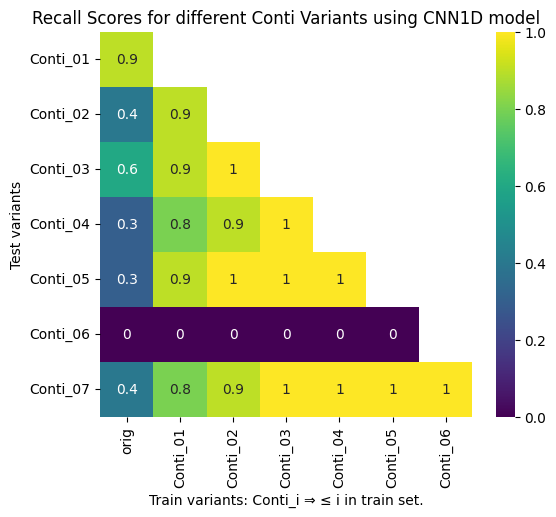

In [373]:
plot_variant_heatmap(cnn1d_run_metrics_150, model_name='CNN1D')